In [155]:
import pandas as pd

In [156]:
df= pd.read_csv("C:\\Users\\User\\Desktop\\python\\ml\\work_from_home_burnout_dataset.csv")

In [157]:
df.head(30)

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low
5,1,Weekday,7.24,9.09,1,4,0,7.53,69.1,54.16,Low
6,1,Weekday,8.09,11.64,6,3,1,5.04,58.4,68.83,Low
7,1,Weekday,7.15,9.98,3,4,0,5.89,46.9,78.89,Medium
8,1,Weekday,8.72,11.80,1,2,0,6.19,49.8,84.39,Medium
9,1,Weekend,5.93,9.17,0,4,0,7.88,55.6,83.86,Medium


In [158]:
df['day_type'].unique

<bound method Series.unique of 0       Weekday
1       Weekend
2       Weekend
3       Weekday
4       Weekend
         ...   
1795    Weekend
1796    Weekend
1797    Weekend
1798    Weekday
1799    Weekend
Name: day_type, Length: 1800, dtype: object>

In [159]:
def daytonumber(day_type):
    if day_type  == "Weekday":
      return 0
    else :
       return 1

In [160]:
df['day_type']  = df['day_type'].apply(daytonumber)

In [201]:
df.head(2)

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,0,9.59,11.86,4,2,0,7.55,91.2,19.17,0
1,1,1,7.38,10.33,4,1,0,6.69,82.0,29.70,0


In [162]:
def risktonumber(burnout_risk):
    if burnout_risk == "Low":
        return 0
    elif burnout_risk == "Medium":
        return 1
    else:
        return 2

In [163]:
df["burnout_risk"]=df["burnout_risk"].apply(risktonumber)

In [164]:
df.head(5)

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,0,9.59,11.86,4,2,0,7.55,91.2,19.17,0
1,1,1,7.38,10.33,4,1,0,6.69,82.0,29.70,0
2,1,1,6.31,8.92,1,2,0,8.87,80.6,32.93,0
3,1,0,8.34,10.70,4,1,1,8.13,70.0,45.47,0
4,1,1,6.97,9.83,1,2,0,5.85,67.1,51.61,0


In [165]:
df.columns

Index(['user_id', 'day_type', 'work_hours', 'screen_time_hours',
       'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours',
       'task_completion_rate', 'burnout_score', 'burnout_risk'],
      dtype='object')

In [166]:
x = df[['work_hours', 'screen_time_hours',
       'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours',
       'task_completion_rate']]
y =df[['burnout_score']]

In [167]:
from sklearn.model_selection import train_test_split

In [168]:
X_train, X_test, y_train, y_test = train_test_split(x ,y)


In [169]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [170]:
y_pred = model.predict(X_test)

In [171]:
from sklearn.metrics import mean_absolute_error , mean_squared_error ,root_mean_squared_error ,r2_score

In [172]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

4.654317699182949
35.133563397393345
5.927357201771574
0.9330060984743174


In [173]:
df

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,0,9.59,11.86,4,2,0,7.55,91.2,19.17,0
1,1,1,7.38,10.33,4,1,0,6.69,82.0,29.70,0
2,1,1,6.31,8.92,1,2,0,8.87,80.6,32.93,0
3,1,0,8.34,10.70,4,1,1,8.13,70.0,45.47,0
4,1,1,6.97,9.83,1,2,0,5.85,67.1,51.61,0
...,...,...,...,...,...,...,...,...,...,...,...
1795,180,1,6.33,8.16,0,4,0,5.59,73.5,31.91,0
1796,180,1,4.70,7.88,0,4,0,6.69,89.8,26.30,0
1797,180,1,3.92,6.39,2,1,0,6.77,74.6,34.07,0
1798,180,0,8.93,11.11,2,5,0,8.28,74.6,38.14,0


In [174]:
from sklearn.linear_model import LinearRegression


In [175]:
df.columns

Index(['user_id', 'day_type', 'work_hours', 'screen_time_hours',
       'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours',
       'task_completion_rate', 'burnout_score', 'burnout_risk'],
      dtype='object')

In [176]:
X = df[['user_id', 'day_type', 'work_hours', 'screen_time_hours',
       'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours',
       'task_completion_rate', 'burnout_score']]
y = df['burnout_risk']

In [177]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1795    0
1796    0
1797    0
1798    0
1799    0
Name: burnout_risk, Length: 1800, dtype: int64

In [178]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [185]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split


In [188]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [189]:
print(X_train.shape)
print(y_train.shape)

(1440, 10)
(1440,)


In [190]:
from sklearn.metrics import accuracy_score, precision_score, recall_score , f1_score, confusion_matrix

In [191]:
accuracy_score(y_test,y_pred)


1.0

In [192]:
precision_score(y_test,y_pred,average= "macro")

1.0

In [193]:
recall_score(y_test,y_pred,average= "macro")

1.0

In [194]:
f1_score(y_test,y_pred,average= "macro")

1.0

In [195]:
confusion_matrix(y_test ,y_pred)

array([[316,   0,   0],
       [  0,  43,   0],
       [  0,   0,   1]])

[Text(0.4, 0.8333333333333334, 'x[9] <= 69.965\nsquared_error = 0.169\nsamples = 1440\nvalue = 0.172'),
 Text(0.2, 0.5, 'squared_error = 0.0\nsamples = 1211\nvalue = 0.0'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[9] <= 110.105\nsquared_error = 0.076\nsamples = 229\nvalue = 1.083'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'squared_error = 0.0\nsamples = 210\nvalue = 1.0'),
 Text(0.8, 0.16666666666666666, 'squared_error = 0.0\nsamples = 19\nvalue = 2.0')]

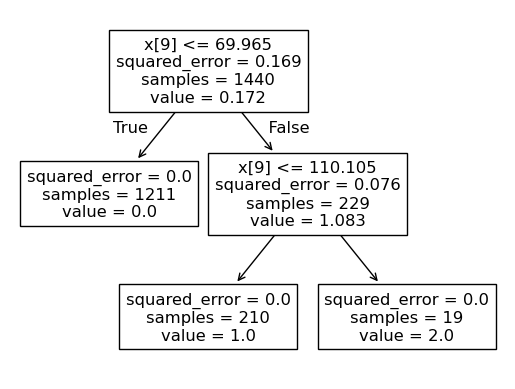

In [200]:
from sklearn.tree import plot_tree
plot_tree(model)
